In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [2]:
df=pd.read_excel(r"FIFA World Cup Dataset.csv.xlsx")
df

,version,team,continent,is_host,goals_scored_last_4y,goals_received_last_4y,wins_last_4y,losses_last_4y,draws_last_4y,world_cup_titles_before,...,world_cup_participations_before,groups_passed_before,round16_before,quarterfinals_before,semifinals_before,finals_before,winner,finalist,semi_finalist,quarter_finalist
0,2026,France,Europe,0,85,32,25,6,7,2,...,16,10,8,9,7,4,NaN,NaN,NaN,NaN
1,2026,Spain,Europe,0,104,32,29,2,8,1,...,16,11,9,6,2,1,NaN,NaN,NaN,NaN
2,2026,Argentina,South America,0,80,14,30,4,3,3,...,18,15,10,10,6,6,NaN,NaN,NaN,NaN
3,2026,England,Europe,0,82,23,26,6,7,1,...,16,13,8,10,3,1,NaN,NaN,NaN,NaN
4,2026,Portugal,Europe,0,98,31,26,5,7,0,...,8,5,4,3,2,0,NaN,NaN,NaN,NaN
5,2026,Brazil,South America,0,58,39,15,10,10,5,...,22,20,12,17,11,6,NaN,NaN,NaN,NaN
6,2026,Netherlands,Europe,0,92,41,21,8,9,0,...,11,11,9,7,5,3,NaN,NaN,NaN,NaN
7,2026,Morocco,Africa,0,100,18,37,2,9,0,...,6,2,2,1,1,0,NaN,NaN,NaN,NaN
8,2026,Belgium,Europe,0,80,32,19,7,10,0,...,14,9,8,3,2,0,NaN,NaN,NaN,NaN
9,2026,Germany,Europe,0,80,47,21,10,7,4,...,20,18,10,16,13,8,NaN,NaN,NaN,NaN


In [3]:
df.shape

(48, 24)

In [4]:
df.isnull().sum()

version                             0
team                                0
continent                           0
is_host                             0
goals_scored_last_4y                0
goals_received_last_4y              0
wins_last_4y                        0
losses_last_4y                      0
draws_last_4y                       0
world_cup_titles_before             0
squad_total_market_value_eur        0
fifa_rank_pre_tournament            0
fifa_points_pre_tournament          0
squad_avg_age                       0
world_cup_participations_before     0
groups_passed_before                0
round16_before                      0
quarterfinals_before                0
semifinals_before                   0
finals_before                       0
winner                             48
finalist                           48
semi_finalist                      48
quarter_finalist                   48
dtype: int64

In [5]:
df.dtypes

version                              int64
team                                object
continent                           object
is_host                              int64
goals_scored_last_4y                 int64
goals_received_last_4y               int64
wins_last_4y                         int64
losses_last_4y                       int64
draws_last_4y                        int64
world_cup_titles_before              int64
squad_total_market_value_eur         int64
fifa_rank_pre_tournament             int64
fifa_points_pre_tournament         float64
squad_avg_age                      float64
world_cup_participations_before      int64
groups_passed_before                 int64
round16_before                       int64
quarterfinals_before                 int64
semifinals_before                    int64
finals_before                        int64
winner                             float64
finalist                           float64
semi_finalist                      float64
quarter_fin

In [6]:
df.describe()

,version,is_host,goals_scored_last_4y,goals_received_last_4y,wins_last_4y,losses_last_4y,draws_last_4y,world_cup_titles_before,squad_total_market_value_eur,fifa_rank_pre_tournament,...,world_cup_participations_before,groups_passed_before,round16_before,quarterfinals_before,semifinals_before,finals_before,winner,finalist,semi_finalist,quarter_finalist
count,48.0,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,4.800000e+01,48.000000,...,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,0.0,0.0,0.0,0.0
mean,2026.0,0.062500,72.395833,37.604167,21.354167,8.604167,9.854167,0.375000,3.117183e+08,32.520833,...,7.041667,4.062500,3.020833,2.437500,1.479167,0.708333,NaN,NaN,NaN,NaN
std,0.0,0.244623,18.037478,12.316292,5.923231,4.150056,3.614331,1.064415,3.450467e+08,23.819346,...,5.946422,5.187572,3.479359,4.078518,2.835861,1.761990,NaN,NaN,NaN,NaN
min,2026.0,0.000000,29.000000,14.000000,9.000000,2.000000,3.000000,0.000000,5.300000e+06,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN
25%,2026.0,0.000000,63.000000,30.000000,17.500000,6.000000,7.000000,0.000000,3.762500e+07,13.750000,...,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN
50%,2026.0,0.000000,72.000000,34.500000,21.500000,8.000000,9.000000,0.000000,1.905750e+08,27.500000,...,6.000000,2.000000,2.000000,0.500000,0.000000,0.000000,NaN,NaN,NaN,NaN
75%,2026.0,0.000000,82.250000,42.000000,26.000000,11.250000,12.000000,0.000000,4.372125e+08,47.000000,...,11.000000,7.250000,5.000000,3.000000,2.000000,0.000000,NaN,NaN,NaN,NaN
max,2026.0,1.000000,110.000000,70.000000,37.000000,20.000000,20.000000,5.000000,1.300000e+09,85.000000,...,22.000000,20.000000,12.000000,17.000000,13.000000,8.000000,NaN,NaN,NaN,NaN


In [7]:
df.columns

Index(['version', 'team', 'continent', 'is_host', 'goals_scored_last_4y',
       'goals_received_last_4y', 'wins_last_4y', 'losses_last_4y',
       'draws_last_4y', 'world_cup_titles_before',
       'squad_total_market_value_eur', 'fifa_rank_pre_tournament',
       'fifa_points_pre_tournament', 'squad_avg_age',
       'world_cup_participations_before', 'groups_passed_before',
       'round16_before', 'quarterfinals_before', 'semifinals_before',
       'finals_before', 'winner', 'finalist', 'semi_finalist',
       'quarter_finalist'],
      dtype='object')

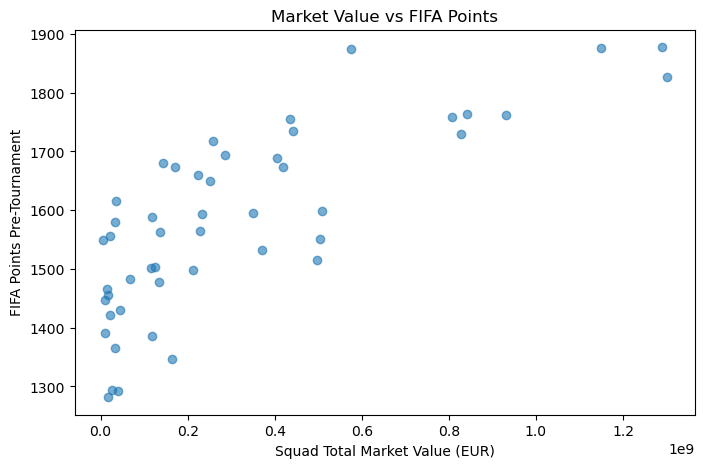

In [8]:
plt.figure(figsize=(8, 5))
plt.scatter(df['squad_total_market_value_eur'], df['fifa_points_pre_tournament'], alpha=0.6)
plt.xlabel('Squad Total Market Value (EUR)')
plt.ylabel('FIFA Points Pre-Tournament')
plt.title('Market Value vs FIFA Points')
plt.show()

In [20]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# 1. Load the 2026 Test Data
# (Make sure to use read_excel since the file is an Excel format despite the name)
df = pd.read_excel("FIFA World Cup Dataset.csv.xlsx", sheet_name="test")

# 2. Select Features
# These features mathematically dictate a team's strength and depth
features = ['fifa_points_pre_tournament', 'squad_total_market_value_eur', 'world_cup_titles_before']

# 3. Scale Features
# MinMaxScaler brings all values into a 0 to 1 range so Market Value doesn't overpower FIFA Points
scaler = MinMaxScaler()
scaled_features = scaler.fit_transform(df[features])

# 4. Apply Weights for a Composite Score
# We weigh FIFA Points highest (50%), followed by Squad Value (40%), and historical pedigree (10%)
weights = [0.5, 0.4, 0.1]
composite_score = (scaled_features * weights).sum(axis=1)

# 5. Normalize into Probabilities
# We divide by the sum of all scores so the total probabilities across all 48 teams equals 100%
df['winning_probability_%'] = (composite_score / composite_score.sum()) * 100

# 6. Extract Team Names and their Winning Possibilities
result_df = df[['team', 'winning_probability_%']].sort_values(by='winning_probability_%', ascending=False).reset_index(drop=True)

# 7. Format and display the top results
result_df['winning_probability_%'] = result_df['winning_probability_%'].round(2).astype(str) + '%'
print("--- 2026 FIFA World Cup: Winning Possibilities ---")
print(result_df.to_string(index=True))

--- 2026 FIFA World Cup: Winning Possibilities ---
                      team winning_probability_%
0                   France                 5.54%
1                  England                 5.18%
2                    Spain                 5.16%
3                   Brazil                 4.66%
4                Argentina                 4.34%
5                  Germany                  4.2%
6                 Portugal                 3.92%
7              Netherlands                 3.83%
8                  Morocco                 3.14%
9                  Belgium                 3.04%
10                 Uruguay                 2.93%
11                 Senegal                 2.75%
12                 Croatia                 2.62%
13                Colombia                 2.55%
14                  Turkey                 2.49%
15                   Japan                 2.28%
16             Switzerland                 2.27%
17                  Norway                 2.24%
18           Unite

Loading data from FIFA World Cup Dataset.csv.xlsx...
Data loaded successfully.

--- Data Shape ---
Total Teams: 48, Total Features: 24

--- Sample of Features Used for Prediction ---
        team  fifa_points_pre_tournament  squad_total_market_value_eur  \
0     France                     1877.32                    1290000000   
1      Spain                     1876.40                    1150000000   
2  Argentina                     1874.81                     575000000   
3    England                     1825.97                    1300000000   
4   Portugal                     1763.83                     841000000   

   world_cup_titles_before  
0                        2  
1                        1  
2                        3  
3                        1  
4                        0  

Scaling features...

   2026 FIFA WORLD CUP: WINNING POSSIBILITIES
                      team winning_probability_display
0                   France                       5.54%
1                  E

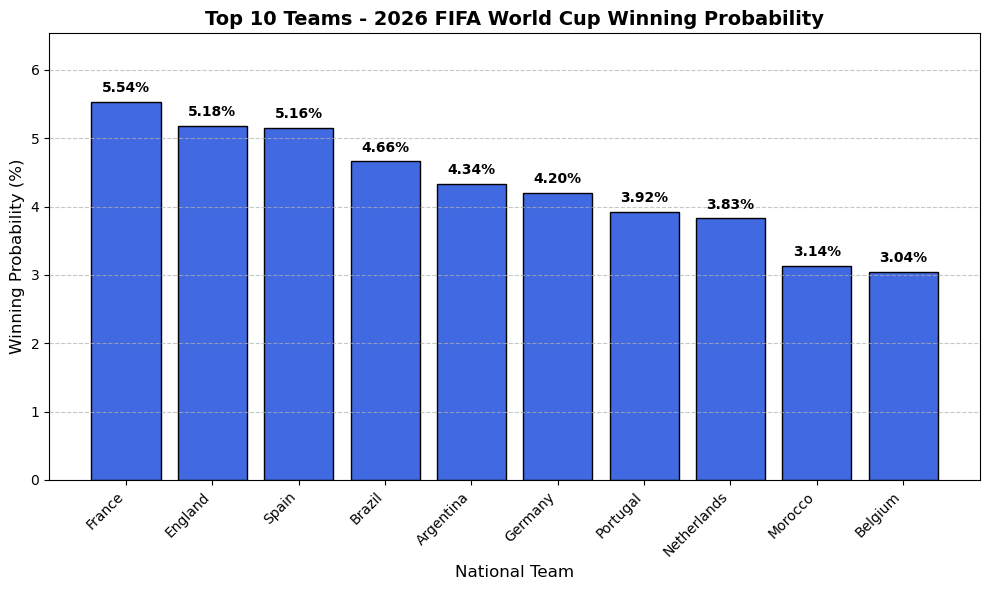

In [19]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# 1. Load the Data
# Using the exact CSV filename you uploaded
file_path = "FIFA World Cup Dataset.csv.xlsx"
print(f"Loading data from {file_path}...")
df = pd.read_excel(r"FIFA World Cup Dataset.csv.xlsx")
print("Data loaded successfully.\n")

# 2. Exploratory Data Analysis (EDA)
print("--- Data Shape ---")
print(f"Total Teams: {df.shape[0]}, Total Features: {df.shape[1]}\n")

# Define the features that dictate a team's strength
features = ['fifa_points_pre_tournament', 'squad_total_market_value_eur', 'world_cup_titles_before']

print("--- Sample of Features Used for Prediction ---")
print(df[['team'] + features].head())

# 3. Data Preprocessing & Feature Scaling
# We must scale the data because Market Value is in the billions and FIFA Points are in the thousands.
# MinMaxScaler brings all values into a 0.0 to 1.0 range so they can be accurately compared.
print("\nScaling features...")
scaler = MinMaxScaler()
scaled_features = scaler.fit_transform(df[features])

# 4. Apply Heuristic Weights
# Assign importance to each feature. 
# 50% weight to current FIFA points, 40% to Squad Market Value, 10% to past World Cup titles
weights = [0.5, 0.4, 0.1]
composite_score = (scaled_features * weights).sum(axis=1)

# 5. Normalize into Winning Probabilities
# We divide each team's score by the sum of all scores.
# This ensures that the combined probability of all 48 teams equals exactly 100%.
df['winning_probability_%'] = (composite_score / composite_score.sum()) * 100

# 6. Formatting the Final Results
# Extract just the team name and probability, sort them from highest to lowest
result_df = df[['team', 'winning_probability_%']].sort_values(by='winning_probability_%', ascending=False).reset_index(drop=True)

# Create a clean string display column with the '%' sign and rounded to 2 decimal places
result_df['winning_probability_display'] = result_df['winning_probability_%'].round(2).astype(str) + '%'

print("\n==================================================")
print("   2026 FIFA WORLD CUP: WINNING POSSIBILITIES")
print("==================================================")
# Print the full ranked list to the console
print(result_df[['team', 'winning_probability_display']].to_string(index=True))

# 7. Visualization
# Plot a bar chart of the Top 10 most likely winners
plt.figure(figsize=(10, 6))
top_10 = result_df.head(10)

# Create the bar chart
bars = plt.bar(top_10['team'], top_10['winning_probability_%'], color='royalblue', edgecolor='black')

# Add the percentage text on top of each bar for readability
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.1, f'{yval:.2f}%', ha='center', va='bottom', fontweight='bold')

plt.title('Top 10 Teams - 2026 FIFA World Cup Winning Probability', fontsize=14, fontweight='bold')
plt.ylabel('Winning Probability (%)', fontsize=12)
plt.xlabel('National Team', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.ylim(0, max(top_10['winning_probability_%']) + 1) # Add some headroom for the labels
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Display the plot
plt.show()